In [1]:
!pip install langchain langchain-community langchain-core langgraph chromadb sentence-transformers pypdf langchain-groq langchain-text-splitters -q 2>/dev/null
print("All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.

In [2]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
print("Key loaded successfully")

Key loaded successfully


In [3]:
from google.colab import files

uploaded = files.upload()
pdf_filename = list(uploaded.keys())[0]
print(f"Uploaded file: {pdf_filename}")

Saving pdf.pdf to pdf.pdf
Uploaded file: pdf.pdf


Cell 4 — Load and chunk the PDF

In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

loader = PyPDFLoader(pdf_filename)
documents = loader.load()
print(f"Pages loaded: {len(documents)}")

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
chunks = splitter.split_documents(documents)
print(f"Total chunks: {len(chunks)}")
print(f"\nSample:\n{chunks[0].page_content}")

Pages loaded: 1
Total chunks: 3

Sample:
TechCorp  Customer  Support  Knowledge  Base   Return  Policy:  Customers  can  return  products  within  30  days  of  purchase.  Items  must  be  unused  and  in  original  packaging.  Refunds  are  processed  within  5-7  business  days.  To  initiate  a  return,  contact  support@techcorp.com.   Shipping  Policy:  Standard  shipping  takes  3-5  business  days.  Express  shipping  takes  1-2  business  days.  Free  shipping  on  orders  above  $50.  We  ship  to  all  major  cities  across


Cell 5 — Create embeddings and store in ChromaDB

In [5]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

print("Loading embedding model... please wait (~1 min first time)")

embedding_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db"
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"ChromaDB ready!")
print(f"Total documents stored: {vectorstore._collection.count()}")

Loading embedding model... please wait (~1 min first time)


/tmp/ipykernel_2484/3507755096.py:6: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

ChromaDB ready!
Total documents stored: 3


Cell 6 — Set up Groq LLM

In [6]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3,
    api_key=os.environ["GROQ_API_KEY"]
)

# Quick test
response = llm.invoke("Say hello in one sentence")
print("LLM test:", response.content)

LLM test: Hello, how can I assist you today?


Cell 7 — Define LangGraph State and all Nodes

In [7]:
from langgraph.graph import StateGraph, END
from langchain_core.prompts import PromptTemplate
from typing import TypedDict

# ── State object ───────────────────────────────────────
class GraphState(TypedDict):
    query: str
    context: str
    answer: str
    needs_escalation: bool
    escalation_reason: str

# ── Node 1: Retrieve and generate answer ───────────────
def process_node(state: GraphState) -> GraphState:
    query = state["query"]

    # Retrieve top 3 relevant chunks
    docs = retriever.invoke(query)
    context = "\n\n".join([d.page_content for d in docs])

    # Build prompt
    prompt = PromptTemplate.from_template("""
You are a helpful assistant. Read the context carefully and answer the question.
Be descriptive. If the context contains any relevant information, use it.

Context:
{context}

Question: {query}

Answer:""")

    chain = prompt | llm
    response = chain.invoke({"context": context, "query": query})
    answer = response.content.strip()

    print(f"\n[Process Node] Query received: {query}")
    print(f"[Process Node] Answer generated: {answer}")

    return {
        **state,
        "context": context,
        "answer": answer
    }

# ── Node 2: Check if escalation is needed ─────────────
def escalation_check_node(state: GraphState) -> GraphState:
    answer = state["answer"].lower()
    query  = state["query"].lower()

    low_confidence_phrases = [
        "i don't know",
        "i cannot",
        "not sure",
        "no information",
        "unclear"
    ]

    sensitive_keywords = [
        "refund", "cancel", "complaint",
        "urgent", "legal", "broken", "damaged"
    ]

    needs_escalation = False
    reason = ""

    if any(phrase in answer for phrase in low_confidence_phrases):
        needs_escalation = True
        reason = "Low confidence — answer not found in knowledge base"

    elif any(word in query for word in sensitive_keywords):
        needs_escalation = True
        reason = "Sensitive topic — needs human review"

    elif len(state["context"].strip()) < 100:
        needs_escalation = True
        reason = "Not enough context retrieved from documents"

    print(f"[Escalation Check] Needs escalation: {needs_escalation}")
    if reason:
        print(f"[Escalation Check] Reason: {reason}")

    return {
        **state,
        "needs_escalation": needs_escalation,
        "escalation_reason": reason
    }

# ── Node 3: Normal output ──────────────────────────────
def output_node(state: GraphState) -> GraphState:
    print("\n" + "="*55)
    print("           BOT RESPONSE")
    print("="*55)
    print(f"  Question : {state['query']}")
    print(f"  Answer   : {state['answer']}")
    print("="*55)
    return state

# ── Node 4: Human in the Loop ─────────────────────────
def hitl_node(state: GraphState) -> GraphState:
    print("\n" + "="*55)
    print("       ESCALATED TO HUMAN AGENT")
    print("="*55)
    print(f"  Question   : {state['query']}")
    print(f"  Reason     : {state['escalation_reason']}")
    print(f"  Bot tried  : {state['answer']}")
    print("-"*55)

    human_response = input("  HUMAN AGENT — Type your response: ")

    final_answer = f"[Human Agent]: {human_response}"
    print(f"\n  Final Answer: {final_answer}")
    print("="*55)

    return {**state, "answer": final_answer}

# ── Routing function ───────────────────────────────────
def route_after_check(state: GraphState) -> str:
    if state["needs_escalation"]:
        return "hitl"
    return "output"

print("All nodes defined successfully")

All nodes defined successfully


Cell 8 — Build and compile LangGraph

In [8]:
graph = StateGraph(GraphState)

# Add all nodes
graph.add_node("process",           process_node)
graph.add_node("escalation_check",  escalation_check_node)
graph.add_node("output",            output_node)
graph.add_node("hitl",              hitl_node)

# Define the flow
graph.set_entry_point("process")
graph.add_edge("process", "escalation_check")

graph.add_conditional_edges(
    "escalation_check",
    route_after_check,
    {
        "output": "output",
        "hitl":   "hitl"
    }
)

graph.add_edge("output", END)
graph.add_edge("hitl",   END)

# Compile
app = graph.compile()
print("LangGraph compiled successfully!")

LangGraph compiled successfully!


Cell 9 — Visualize LangGraph

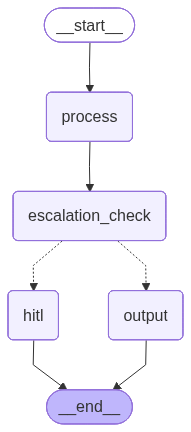

Graph saved as rag_graph.png


In [9]:
from IPython.display import Image, display

try:
    img_bytes = app.get_graph().draw_mermaid_png()
    with open("rag_graph.png", "wb") as f:
        f.write(img_bytes)
    display(Image("rag_graph.png"))
    print("Graph saved as rag_graph.png")
except Exception as e:
    print("Could not render image:", e)
    print("\nFlow is:")
    print("process → escalation_check → output (normal)")
    print("                           → hitl   (escalation)")

Cell 10 — Test normal queries

In [10]:
def run_query(query: str):
    initial_state = GraphState(
        query=query,
        context="",
        answer="",
        needs_escalation=False,
        escalation_reason=""
    )
    result = app.invoke(initial_state)
    return result

# Change this to something relevant to your PDF
run_query("What is this document about?")


[Process Node] Query received: What is this document about?
[Process Node] Answer generated: This document appears to be the Customer Support Knowledge Base of TechCorp, outlining various policies related to customer support, returns, shipping, cancellations, product warranty, and payment. It serves as a comprehensive guide for customers to understand the terms and conditions of their transactions with TechCorp.

The document covers essential information such as:

1. Return Policy: Conditions for returning products, including the timeframe, unused status, and original packaging requirements.
2. Shipping Policy: Details on shipping options, delivery times, and free shipping conditions.
3. Cancellation Policy: Information on cancelling orders, including the timeframe and refund process.
4. Contact Support: Details on how to reach TechCorp's customer support team through email, phone, and working hours.
5. Product Warranty: Explanation of the warranty coverage, including manufacturing de

{'query': 'What is this document about?',
 'context': 'TechCorp  Customer  Support  Knowledge  Base   Return  Policy:  Customers  can  return  products  within  30  days  of  purchase.  Items  must  be  unused  and  in  original  packaging.  Refunds  are  processed  within  5-7  business  days.  To  initiate  a  return,  contact  support@techcorp.com.   Shipping  Policy:  Standard  shipping  takes  3-5  business  days.  Express  shipping  takes  1-2  business  days.  Free  shipping  on  orders  above  $50.  We  ship  to  all  major  cities  across\n\navailable  in  selected  cities.   Cancellation  Policy:  Orders  can  be  cancelled  within  24  hours  of  placing.  Once  shipped,  orders  cannot  be  cancelled.  Cancellation  refunds  take  3-5  business  days.   Contact  Support:  Email:  support@techcorp.com  Phone:  1-800-TECH-999  Working  hours:  Monday  to  Friday,  9am  to  6pm  IST.\n\n$50.  We  ship  to  all  major  cities  across  India.   Product  Warranty:  All  products 


Cell 11 — Test more queries

In [12]:
print("--- Test 2: Shipping ---")
run_query("How long does shipping take?")

print("\n--- Test 3: Payment ---")
run_query("What payment methods do you accept?")

print("\n--- Test 4: Unknown query ---")
run_query("What is the CEO name?")

--- Test 2: Shipping ---

[Process Node] Query received: How long does shipping take?
[Process Node] Answer generated: According to the TechCorp Shipping Policy, there are two types of shipping options available:

1. **Standard Shipping**: This takes 3-5 business days.
2. **Express Shipping**: This takes 1-2 business days.

Additionally, TechCorp offers **Free Shipping** on orders above $50, and they ship to all major cities across India.
[Escalation Check] Needs escalation: False

           BOT RESPONSE
  Question : How long does shipping take?
  Answer   : According to the TechCorp Shipping Policy, there are two types of shipping options available:

1. **Standard Shipping**: This takes 3-5 business days.
2. **Express Shipping**: This takes 1-2 business days.

Additionally, TechCorp offers **Free Shipping** on orders above $50, and they ship to all major cities across India.

--- Test 3: Payment ---

[Process Node] Query received: What payment methods do you accept?
[Process Node] An

{'query': 'What is the CEO name?',
 'context': 'available  in  selected  cities.   Cancellation  Policy:  Orders  can  be  cancelled  within  24  hours  of  placing.  Once  shipped,  orders  cannot  be  cancelled.  Cancellation  refunds  take  3-5  business  days.   Contact  Support:  Email:  support@techcorp.com  Phone:  1-800-TECH-999  Working  hours:  Monday  to  Friday,  9am  to  6pm  IST.\n\nTechCorp  Customer  Support  Knowledge  Base   Return  Policy:  Customers  can  return  products  within  30  days  of  purchase.  Items  must  be  unused  and  in  original  packaging.  Refunds  are  processed  within  5-7  business  days.  To  initiate  a  return,  contact  support@techcorp.com.   Shipping  Policy:  Standard  shipping  takes  3-5  business  days.  Express  shipping  takes  1-2  business  days.  Free  shipping  on  orders  above  $50.  We  ship  to  all  major  cities  across\n\n$50.  We  ship  to  all  major  cities  across  India.   Product  Warranty:  All  products  come  

Cell 12 — Test HITL escalation

In [13]:
# These will trigger HITL — type a response when prompted
print("--- HITL Test: Sensitive topic ---")
run_query("I want a refund immediately")

--- HITL Test: Sensitive topic ---

[Process Node] Query received: I want a refund immediately
[Process Node] Answer generated: I understand your concern about getting a refund immediately. However, according to the provided information, TechCorp's cancellation refund process takes 3-5 business days. This is as per their Cancellation Policy, which states that cancellation refunds take 3-5 business days.

Unfortunately, it's not possible to get a refund immediately, as the company has a standard processing time for refunds. If you have already cancelled your order within the 24-hour window, you can expect the refund to be processed within the mentioned timeframe.

If you have any further concerns or questions, you can reach out to TechCorp's Customer Support team via email at support@techcorp.com or by calling them at 1-800-TECH-999 during their working hours (Monday to Friday, 9am to 6pm IST). They will be happy to assist you with any queries or concerns you may have.
[Escalation Check

{'query': 'I want a refund immediately',
 'context': 'available  in  selected  cities.   Cancellation  Policy:  Orders  can  be  cancelled  within  24  hours  of  placing.  Once  shipped,  orders  cannot  be  cancelled.  Cancellation  refunds  take  3-5  business  days.   Contact  Support:  Email:  support@techcorp.com  Phone:  1-800-TECH-999  Working  hours:  Monday  to  Friday,  9am  to  6pm  IST.\n\nTechCorp  Customer  Support  Knowledge  Base   Return  Policy:  Customers  can  return  products  within  30  days  of  purchase.  Items  must  be  unused  and  in  original  packaging.  Refunds  are  processed  within  5-7  business  days.  To  initiate  a  return,  contact  support@techcorp.com.   Shipping  Policy:  Standard  shipping  takes  3-5  business  days.  Express  shipping  takes  1-2  business  days.  Free  shipping  on  orders  above  $50.  We  ship  to  all  major  cities  across\n\n$50.  We  ship  to  all  major  cities  across  India.   Product  Warranty:  All  products  